C:\Users\refah\OneDrive\Attachments\Diabetes-prediction-project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


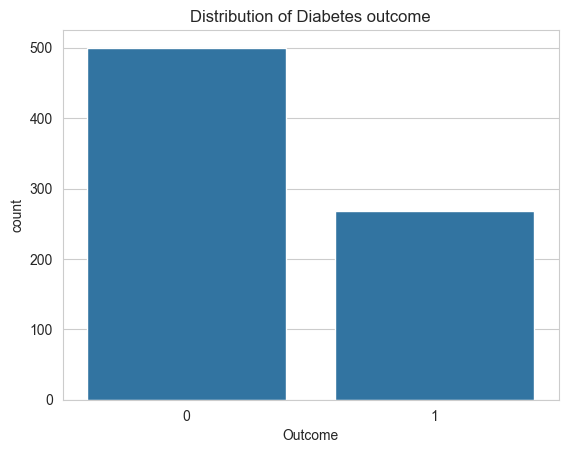

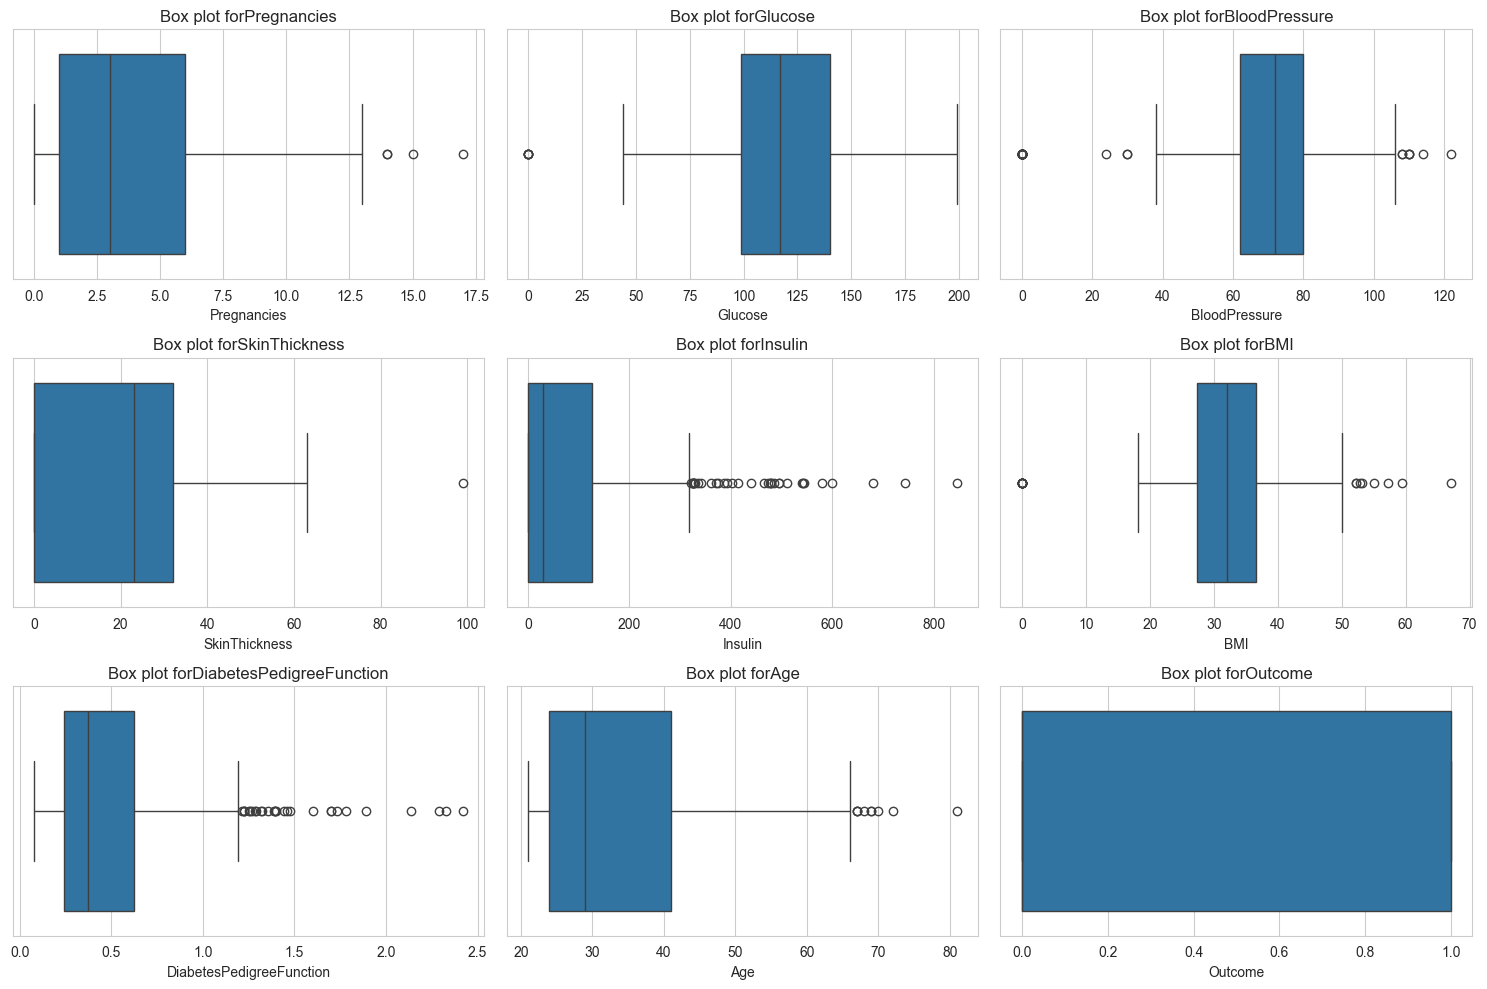

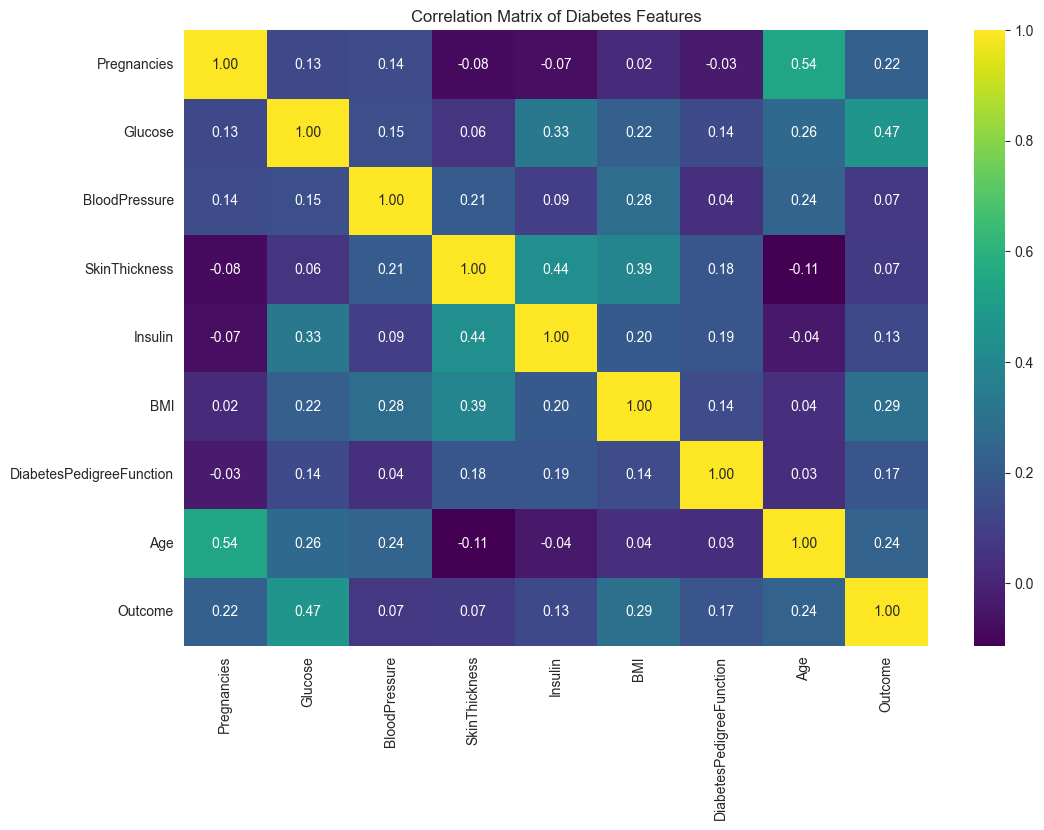

A peek at the data in the identified columns:
   Glucose  BloodPressure  SkinThickness  Insulin   BMI
0      148             72             35        0  33.6
1       85             66             29        0  26.6
2      183             64              0        0  23.3
3       89             66             23       94  28.1
4      137             40             35      168  43.1
Data after replacing 0s with NaN:
   Glucose  BloodPressure  SkinThickness  Insulin   BMI
0    148.0           72.0           35.0      NaN  33.6
1     85.0           66.0           29.0      NaN  26.6
2    183.0           64.0            NaN      NaN  23.3
3     89.0           66.0           23.0     94.0  28.1
4    137.0           40.0           35.0    168.0  43.1
Count of missing values in each column after cleaning:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
D

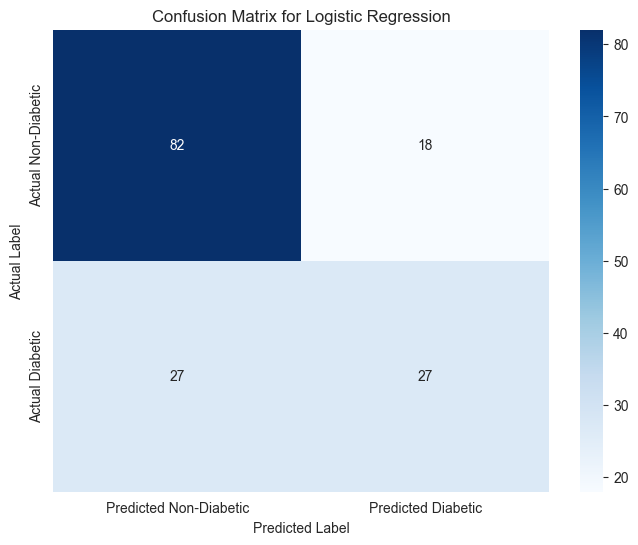

First 20 predictions from the K-NN model:
[1. 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 1. 1. 0. 1. 0.]

First 20 true labels (y_test):
[0. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 0.]

Shape of k-NN predictions array (y_pred_knn) : (154,)
Shape of true label array (y_test) : (154,)
--- K-Nearest Neighbors (k-NN) Classification Report ---
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.80      0.83      0.81       100
    Diabetic (1)       0.66      0.61      0.63        54

        accuracy                           0.75       154
       macro avg       0.73      0.72      0.72       154
    weighted avg       0.75      0.75      0.75       154


--- K-Nearest Neighbors (k-NN) Confusion Matrix ---


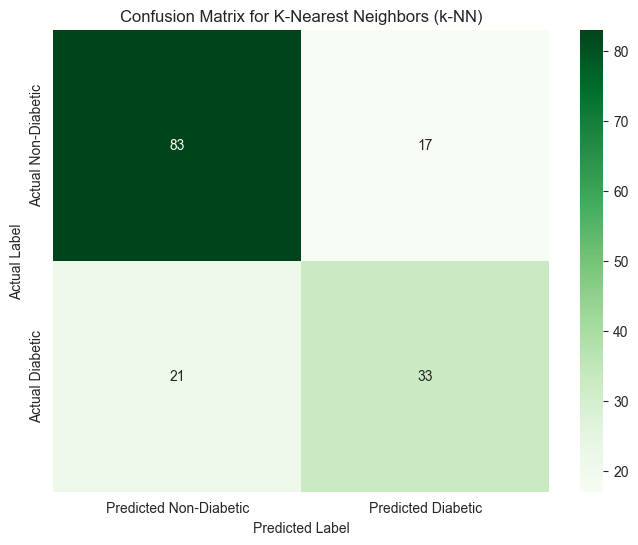

--- F1-Score Comparison ---
Logistic Regression F1-Score (Diabetic Class): 0.5455
K-Nearest Neighbors F1-Score (Diabetic Class): 0.6346

--- Initial Conclusion ---
Based on the F1-Score, the K-Nearest Neighbors model is the initial best performer.
--- Error Analysis: Logistic Regression vs. k-NN ---
\n--- Logistic Regression ---
False Positives (Predicted Diabetic, Was Healthy): 18
False Negatives (Predicted Healthy, Was Diabetic): 27  <-- MOST CRITICAL ERROR
\n--- K-Nearest Neighbors ---
False Positives (Predicted Diabetic, Was Healthy): 17
False Negatives (Predicted Healthy, Was Diabetic): 21  <-- MOST CRITICAL ERROR
\n--- Final Conclusion ---
The K-Nearest Neighbors model is the superior baseline.
It produced 6 fewer False Negatives, which is our primary concern.
Random Forest model initialzed and trained sucessfully:
RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)


C:\Users\refah\OneDrive\Attachments\Diabetes-prediction-project\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [14:10:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost model initialized and trained successfully:
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)
--- Random Forest Classifier Report ---
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.78      0.83      0.81       100
    Diabetic 

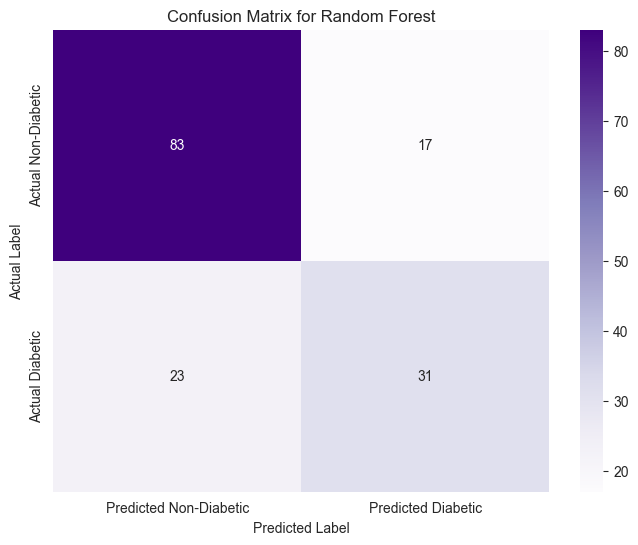



--- XGBoost Classifier Report ---
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.79      0.83      0.81       100
    Diabetic (1)       0.65      0.59      0.62        54

        accuracy                           0.75       154
       macro avg       0.72      0.71      0.72       154
    weighted avg       0.74      0.75      0.74       154


--- XGBoost Confusion Matrix ---


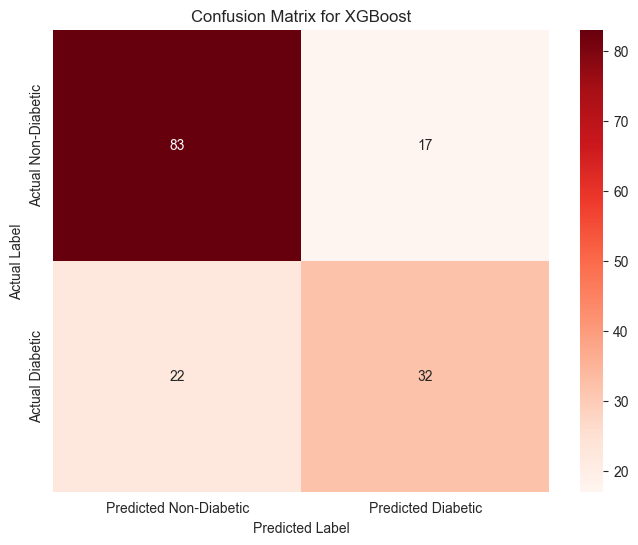

--- Model Performance Comparison ---


,F1-Score,Recall,Precision,False Negatives,False Positives
Logistic Regression,0.545455,0.500000,0.600000,27,18
K-Nearest Neighbors,0.634615,0.611111,0.660000,21,17
Random Forest,0.607843,0.574074,0.645833,23,17
XGBoost,0.621359,0.592593,0.653061,22,17


The selected best performing model is: Random Forest
This model will be used for the next step: Hyperparameter Tuning.
The selected best performing model is: Random Forest
This model will be used for the next step: Hyperparameter Tuning.
GridsearchCV class imported sucessfully. Ready to build the tuning engine.
--- GridSearchCV Tuning Engine Assembled and Ready ---
GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15, None],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='recall', verbose=2)
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
--- Optimal Hyperparameters Found by Grid Search

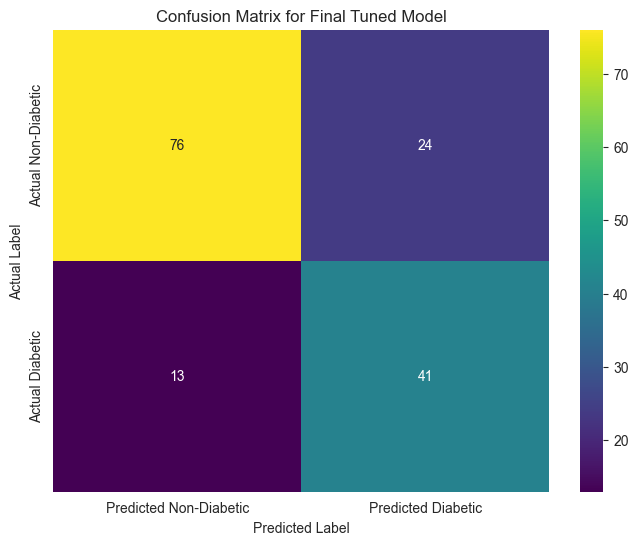



--- Performance Showdown: Tuned vs. Untuned Model on the Test Set ---


,Original Random Forest,Final Tuned Random Forest
Metric,,
F1-Score,0.6078,0.6891
Recall,0.5741,0.7593
False Negatives (Critical),23,13


--- Feature Importances from the Final Model ---


,Feature,Importance
0,Glucose,0.403148
1,BMI,0.193159
2,Age,0.122805
3,Insulin,0.091622
4,DiabetesPedigreeFunction,0.074470
5,SkinThickness,0.041263
6,Pregnancies,0.040122
7,BloodPressure,0.033409


--- SHAP Explainer Object Created Successfully ---
Explainer type: <class 'shap.explainers._tree.TreeExplainer'>
The explainer is now ready to calculate SHAP values.
--- SHAP Values Object ---
Type of the output: <class 'shap._explanation.Explanation'>

Shape of the SHAP values array: (154, 8, 2)
This means we have 154 explanations (one for each test patient),
and each explanation has 8 values (one for each feature).

SHAP values for the first patient in the test set:
[[-0.03188301  0.03188301]
 [-0.29636821  0.29636821]
 [ 0.00546934 -0.00546934]
 [-0.00283447  0.00283447]
 [-0.028765    0.028765  ]
 [ 0.07491195 -0.07491195]
 [ 0.01597393 -0.01597392]
 [-0.05797612  0.05797612]]

Original feature values for the first patient:
[ 0.96054099  1.24515673 -0.66367599 -0.00476614 -0.16143729 -0.74014536
 -0.55579092  0.56103382]
Plotting dependence for the most important feature: 'Glucose'
Coloring by the second most important feature: 'BMI'


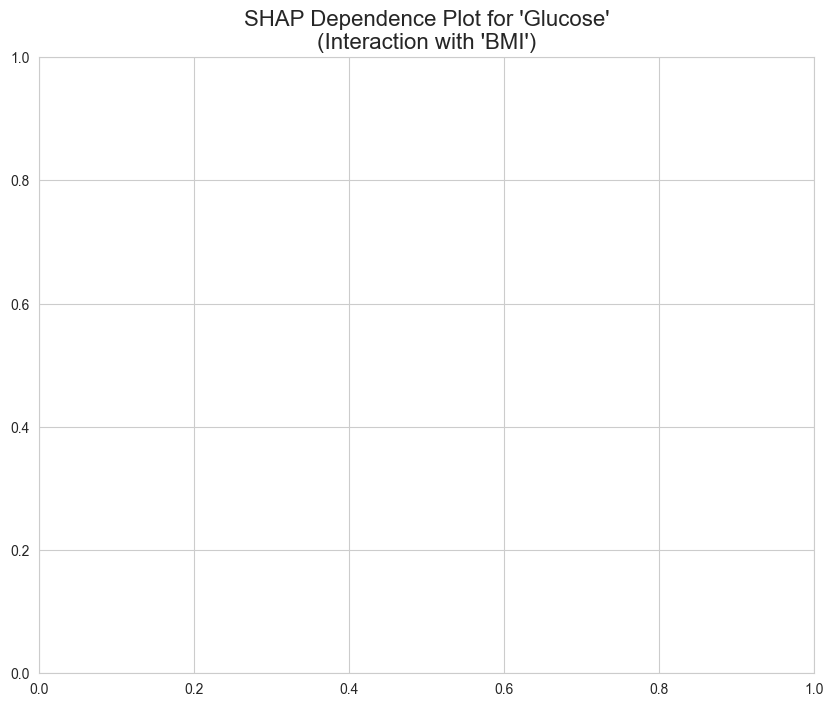

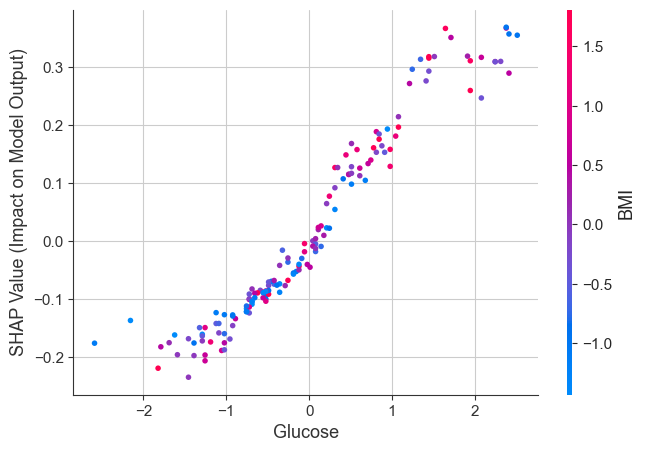

Pipeline class imported successfully. We are now ready to build our production-ready workflow.
--- Machine Learning Pipeline Blueprint ---
Step Name: 'imputer', Object: SimpleImputer
Step Name: 'scaler', Object: StandardScaler
Step Name: 'classifier', Object: RandomForestClassifier
--- Machine Learning Pipeline Assembled Successfully ---
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=5,
                                        max_features='log2', min_samples_leaf=4,
                                        n_estimators=200, n_jobs=-1,
                                        random_state=42))])
Shape of raw X_train: (614, 8)
Using this raw data to train the entire pipeline.

Training the final_pipeline...

--- Pipeline Training Complete! ---
The 'final_pipeline' object is now a fully trained, ready-to-use prediction engine

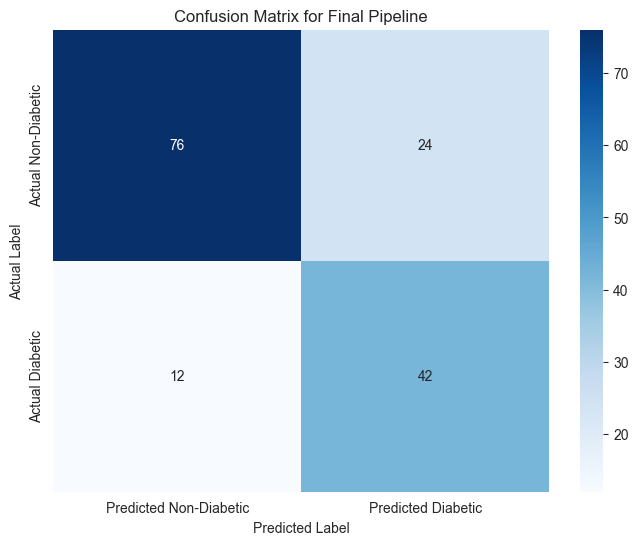



--- Sanity Check: Manual Workflow vs. Pipeline Workflow ---
Pipeline F1-score (Diabetic): 0.7
Pipeline Recall (Diabetic): 0.7777777777777778
Pipeline False Negatives: 12


,Original Random Forest,Final Tuned Random Forest,Pipeline Workflow
Metric,,,
F1-Score,0.607843,0.689076,0.700000
Recall,0.574074,0.759259,0.777778
False Negatives (Critical),23.000000,13.000000,12.000000


--- Pipeline Saved Successfully! ---

The trained pipeline has been saved to the file: 'diabetes_pipeline.joblib'
This file contains the entire workflow: imputer, scaler, and the final trained model.


--- Verification Step ---
Loading the pipeline from the file to test it...
Pipeline loaded successfully. Preparing a sample for prediction...

--- Prediction on a Sample Patient ---
Sample Patient Data:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
44,7,159.0,64.0,NaN,NaN,27.4,0.294,40



Model Prediction (0=Non-Diabetic, 1=Diabetic): 1
Prediction Probabilities (for [Non-Diabetic, Diabetic]): [0.25897845 0.74102155]


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
import shap
from sklearn.pipeline import Pipeline

sns.set_style('whitegrid')
df = pd.read_csv('diabetes.csv')

df.head()
df.tail()
df.info()
df.describe()
df.nunique()

ax = sns.countplot(x='Outcome', data=df)
ax.set_title('Distribution of Diabetes outcome')
plt.show()

fig, axes= plt.subplots(3, 3, figsize=(15, 10))
for ax, col in zip(axes.flatten(), df.columns):
    sns.boxplot(x=col, data=df, ax=ax)
    ax.set_title(f'Box plot for{col}')
plt.tight_layout()
plt.show()

correlation_matrix = df.corr()
correlation_matrix
plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix, 
    annot=True,        # show numbers in the heatmap  
    cmap='viridis',    # color style  
    fmt='.2f'          # show 2 decimal places
)
plt.title('Correlation Matrix of Diabetes Features')
plt.show()
#cleaning & preprocessing.......................................................................................................................

columns_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("A peek at the data in the identified columns:")
print(df[columns_with_zeros].head())
df[columns_with_zeros] = df[columns_with_zeros].replace(0, np.nan)
print("Data after replacing 0s with NaN:")
print(df[columns_with_zeros].head())

missing_values_count = df.isnull().sum()
print("Count of missing values in each column after cleaning:")
print(missing_values_count)


imputer = SimpleImputer(strategy='median')
imputed_data_array = imputer.fit_transform(df)
df_imputed = pd.DataFrame(imputed_data_array, columns=df.columns)
print("Missing values after implutation:")
print(df_imputed.isnull().sum())
print("\nData after imputation:")
print(df_imputed.head())
df = df_imputed

X = df.drop('Outcome', axis=1)
y = df['Outcome']
print("First 5 rows of our features (X):")
print(X.head())
print("\nFirst 5 rows of our target (y):")
print(y.head())
print(f"\nShape of X:{X.shape}")
print(f"Shape of y: {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Shape of original X:",X.shape)
print("Shape of original y:",y.shape)
print("_" * 30)
print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("_" * 30)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)
scaler = StandardScaler()
print("StandardScaler object created successfully:")
print(scaler)

scaler.fit(X_train)
print("Learned Mean values for each feature (from X_train):")
print(scaler.mean_)
print("\nLearned Standard Deviation values for each feature (from X_train):")
print(scaler.scale_)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)
print("First 5 rows of scaled training data (X_train_scaled):")
print(X_train_scaled.head())
print("\nStatistical summary of scaled training data:")
print(X_train_scaled.describe())

#trainig........................................................................................................................

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)
print("LogisticRegression class imported successfully:")
print(log_reg)

knn = KNeighborsClassifier(n_neighbors=5) 
knn.fit(X_train_scaled, y_train)
print("K-Nearest Neighbors model has been successfully trained (fitted).")
# print("KNeighborsClassifier class imported successfully:")
print(knn)
#evaluation..................................................................................................................................
y_pred_log_reg = log_reg.predict(X_test_scaled)
print("First 20 predictions from the Logistic Regression model: ")
print(y_pred_log_reg[:20])
print("\nFirst 20 true  labels (y_test):")
print(y_test[:20].values)
print(f"\nShape of prediction array (y_pred_log_reg): {y_pred_log_reg.shape}")
print(f"Shape of true label array (y_test): {y_test.shape}")
# Import the necessary evaluation tools from scikit-learn

from sklearn.metrics import classification_report, confusion_matrix

# We also import visualization libraries to create a more readable confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- Generate the Classification Report ---
# This function takes the true labels (y_test) and the predicted labels (y_pred_log_reg)
# and returns a text report showing the main classification metrics.
print("--- Logistic Regression Classification Report ---")
# The target_names parameter allows us to label our classes for better readability.
print(classification_report(y_test, y_pred_log_reg, target_names=['Non-Diabetic (0)', 'Diabetic (1)']))

# --- Generate and Visualize the Confusion Matrix ---
print("\\n--- Logistic Regression Confusion Matrix ---")
# First, we compute the confusion matrix which returns a 2x2 numpy array
cm = confusion_matrix(y_test, y_pred_log_reg)

# Now, we use seaborn's heatmap to visualize this matrix
plt.figure(figsize=(8, 6)) # Set the figure size for better readability
sns.heatmap(cm, 
            annot=True,      # Annotate the cells with the numeric value
            fmt='d',         # Format the numbers as integers
            cmap='Blues',    # Use a blue color map
            xticklabels=['Predicted Non-Diabetic', 'Predicted Diabetic'],
            yticklabels=['Actual Non-Diabetic', 'Actual Diabetic'])

plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

y_pred_knn = knn.predict(X_test_scaled)
print("First 20 predictions from the K-NN model:")
print(y_pred_knn[:20])
print("\nFirst 20 true labels (y_test):")
print(y_test[:20].values)
print(f"\nShape of k-NN predictions array (y_pred_knn) : {y_pred_knn.shape}")
print(f"Shape of true label array (y_test) : {y_test.shape}")
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
print("--- K-Nearest Neighbors (k-NN) Classification Report ---")
print(classification_report(y_test, y_pred_knn, target_names=['Non-Diabetic (0)', 'Diabetic (1)']))
print("\n--- K-Nearest Neighbors (k-NN) Confusion Matrix ---")
# Compute the confusion matrix using the k-NN predictions
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, 
            annot=True, 
            fmt='d', 
            cmap='Greens', # Using a different color map to visually distinguish from the last plot
            xticklabels=['Predicted Non-Diabetic', 'Predicted Diabetic'],
            yticklabels=['Actual Non-Diabetic', 'Actual Diabetic'])

plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix for K-Nearest Neighbors (k-NN)')
plt.show()
#campare f-1 secore 
from sklearn.metrics import classification_report
# Get classification report as dictionary for Logistic Regression
report_log_reg = classification_report(
    y_test, 
    y_pred_log_reg, 
    target_names=['Non-Diabetic (0)', 'Diabetic (1)'], 
    output_dict=True
)

# Get classification report as dictionary for KNN
report_knn = classification_report(
    y_test, 
    y_pred_knn, 
    target_names=['Non-Diabetic (0)', 'Diabetic (1)'], 
    output_dict=True
)

# Extract only F1-score of Diabetic class (1)
f1_log_reg = report_log_reg['Diabetic (1)']['f1-score']
f1_knn = report_knn['Diabetic (1)']['f1-score']

print(f"--- F1-Score Comparison ---")
print(f"Logistic Regression F1-Score (Diabetic Class): {f1_log_reg:.4f}")
print(f"K-Nearest Neighbors F1-Score (Diabetic Class): {f1_knn:.4f}")

print("\n--- Initial Conclusion ---")
if f1_log_reg > f1_knn:
    print("Based on the F1-Score, the Logistic Regression model is the initial best performer.")
elif f1_knn > f1_log_reg:
    print("Based on the F1-Score, the K-Nearest Neighbors model is the initial best performer.")
else:
    print("Based on the F1-Score, both models have nearly identical performance.")

# --- Extracting counts for Logistic Regression ---
tn_log_reg = cm[0, 0]
fp_log_reg = cm[0, 1]
fn_log_reg = cm[1, 0]
tp_log_reg = cm[1, 1]

# --- Extracting counts for K-Nearest Neighbors ---
tn_knn = cm_knn[0, 0]
fp_knn = cm_knn[0, 1]
fn_knn = cm_knn[1, 0]
tp_knn = cm_knn[1, 1]

# --- Printing a clear, comparative analysis ---
print("--- Error Analysis: Logistic Regression vs. k-NN ---")
print("\\n--- Logistic Regression ---")
print(f"False Positives (Predicted Diabetic, Was Healthy): {fp_log_reg}")
print(f"False Negatives (Predicted Healthy, Was Diabetic): {fn_log_reg}  <-- MOST CRITICAL ERROR")

print("\\n--- K-Nearest Neighbors ---")
print(f"False Positives (Predicted Diabetic, Was Healthy): {fp_knn}")
print(f"False Negatives (Predicted Healthy, Was Diabetic): {fn_knn}  <-- MOST CRITICAL ERROR")

print("\\n--- Final Conclusion ---")
if fn_log_reg < fn_knn:
    print(f"The Logistic Regression model is the superior baseline.")
    print(f"It produced {fn_knn - fn_log_reg} fewer False Negatives, which is our primary concern.")
elif fn_knn < fn_log_reg:
    print(f"The K-Nearest Neighbors model is the superior baseline.")
    print(f"It produced {fn_log_reg - fn_knn} fewer False Negatives, which is our primary concern.")
else:
    print("Both models produced the same number of False Negatives.")
    print("We can fall back to the F1-score to make our final decision.")
#advanced model training....................................................................................................................................
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
rf_model.fit(X_train_scaled, y_train)
print("Random Forest model initialzed and trained sucessfully:")
print(rf_model)
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_scaled, y_train)
print("XGBoost model initialized and trained successfully:")
print(xgb_model)
#EVALUATE TWO MODEL
# The necessary evaluation functions should already be imported from our baseline evaluation step.
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_rf = rf_model.predict(X_test_scaled)

print("--- Random Forest Classifier Report ---")
print(classification_report(y_test, y_pred_rf, target_names=['Non-Diabetic (0)', 'Diabetic (1)']))

print("\n--- Random Forest Confusion Matrix ---")
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, 
            annot=True, 
            fmt='d', 
            cmap='Purples', # Using a new color map to distinguish from baselines
            xticklabels=['Predicted Non-Diabetic', 'Predicted Diabetic'],
            yticklabels=['Actual Non-Diabetic', 'Actual Diabetic'])

plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
print(classification_report(y_test, y_pred_xgb, target_names=['Non-Diabetic (0)', 'Diabetic (1)']))
print("\n--- XGBoost Confusion Matrix ---")
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, 
            annot=True, 
            fmt='d', 
            cmap='Reds', # Another distinct color map
            xticklabels=['Predicted Non-Diabetic', 'Predicted Diabetic'],
            yticklabels=['Actual Non-Diabetic', 'Actual Diabetic'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix for XGBoost')
plt.show()
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

report_log_reg = classification_report(y_test, y_pred_log_reg, target_names=['Non-Diabetic (0)', 'Diabetic (1)'], output_dict=True)
report_knn = classification_report(y_test, y_pred_knn, target_names=['Non-Diabetic (0)', 'Diabetic (1)'], output_dict=True)
report_rf = classification_report(y_test, y_pred_rf, target_names=['Non-Diabetic (0)', 'Diabetic (1)'], output_dict=True)
report_xgb = classification_report(y_test, y_pred_xgb, target_names=['Non-Diabetic (0)', 'Diabetic (1)'], output_dict=True)

performance_summary = {
    'Logistic Regression': {
        'Precision': report_log_reg['Diabetic (1)']['precision'],
        'Recall': report_log_reg['Diabetic (1)']['recall'],
        'F1-Score': report_log_reg['Diabetic (1)']['f1-score'],
    },
    'K-Nearest Neighbors': {
        'Precision': report_knn['Diabetic (1)']['precision'],
        'Recall': report_knn['Diabetic (1)']['recall'],
        'F1-Score': report_knn['Diabetic (1)']['f1-score'],
    },
    'Random Forest': {
        'Precision': report_rf['Diabetic (1)']['precision'],
        'Recall': report_rf['Diabetic (1)']['recall'],
        'F1-Score': report_rf['Diabetic (1)']['f1-score'],
    },
    'XGBoost': {
        'Precision': report_xgb['Diabetic (1)']['precision'],
        'Recall': report_xgb['Diabetic (1)']['recall'],
        'F1-Score': report_xgb['Diabetic (1)']['f1-score'],
    }
}

all_cms = {
    'Logistic Regression': cm,
    'K-Nearest Neighbors': cm_knn,
    'Random Forest': cm_rf,
    'XGBoost': cm_xgb
}

for model_name, model_cm in all_cms.items():
    performance_summary[model_name]['False Positives'] = model_cm[0, 1]
    performance_summary[model_name]['False Negatives'] = model_cm[1, 0]

performance_df = pd.DataFrame.from_dict(performance_summary, orient='index')

performance_df = performance_df[['F1-Score', 'Recall', 'Precision', 'False Negatives', 'False Positives']]

print("--- Model Performance Comparison ---")
display(performance_df.style.background_gradient(cmap='viridis', subset=['F1-Score', 'Recall'])
                          .highlight_min(subset=['False Negatives'], color='lightcoral'))

best_model = rf_model
best_model_name = "Random Forest" # Change to "Random Forest" if that was your choice
print(f"The selected best performing model is: {best_model_name}")
print("This model will be used for the next step: Hyperparameter Tuning.")

# hyperparameter tuning..........................................................................................................................................................................................

best_model = rf_model
best_model_name = "Random Forest"

print(f"The selected best performing model is: {best_model_name}")
print("This model will be used for the next step: Hyperparameter Tuning.")
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

print("GridsearchCV class imported sucessfully. Ready to build the tuning engine.")
grid_search = GridSearchCV(
    estimator=best_model,
    param_grid=param_grid_rf,
    scoring='recall',
    cv=5,
    n_jobs=-1,
    verbose=2
)
print("--- GridSearchCV Tuning Engine Assembled and Ready ---")
print(grid_search)

grid_search.fit(X_train_scaled, y_train)
print("--- Optimal Hyperparameters Found by Grid Search ---")
best_params = grid_search.best_params_
print(best_params)

best_cv_score = grid_search.best_score_
print("--- Best Cross-Validation Score from Tuning ---")
print(f"The best average Recall achieved during 5-fold cross-validation was: {best_cv_score:.4f}")
try:
    original_f1_score = performance_df.loc[best_model_name, 'F1-Score']
    print(f"\n--- Performance Improvement Analysis ---")
    print(f"Original, untuned model's F1-score on the test set: {original_f1_score:.4f}")
    print(f"Tuned model's cross-validation F1-score: {best_cv_score:.4f}")
    
    improvement = best_cv_score - original_f1_score
    print(f"Improvement from hyperparameter tuning: {improvement:+.4f}")
    
except NameError:
    print("\nRun the previous steps to create 'performance_df' and 'best_model_name' for a full comparison.")
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import

final_model = grid_search.best_estimator_

print("--- The Final Tuned Model ---")
print(final_model)
y_pred_final = final_model.predict(X_test_scaled)
print("\n\n--- Final Tuned Model Classification Report (on Test Set) ---")
report_final = classification_report(y_test, y_pred_final, target_names=['Non-Diabetic (0)', 'Diabetic (1)'], output_dict=True)
print(classification_report(y_test, y_pred_final, target_names=['Non-Diabetic (0)', 'Diabetic (1)']))
print("\n--- Final Tuned Model Confusion Matrix (on Test Set) ---")
cm_final = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_final,
            annot=True,
            fmt='d',
            cmap='viridis', 
            xticklabels=['Predicted Non-Diabetic', 'Predicted Diabetic'],
            yticklabels=['Actual Non-Diabetic', 'Actual Diabetic'])

plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix for Final Tuned Model')
plt.show()
print("\n\n--- Performance Showdown: Tuned vs. Untuned Model on the Test Set ---")
final_f1 = report_final['Diabetic (1)']['f1-score']
final_recall = report_final['Diabetic (1)']['recall']
final_fn = cm_final[1, 0] # False Negatives
original_f1 = performance_df.loc[best_model_name, 'F1-Score']
original_recall = performance_df.loc[best_model_name, 'Recall']
original_fn = performance_df.loc[best_model_name, 'False Negatives']
comparison_data = {
    'Metric': ['F1-Score', 'Recall', 'False Negatives (Critical)'],
    f'Original {best_model_name}': [original_f1, original_recall, original_fn],
    f'Final Tuned {best_model_name}': [final_f1, final_recall, final_fn]
}
comparison_df = pd.DataFrame(comparison_data)
comparison_df.set_index('Metric', inplace=True)
display(comparison_df.style.format('{:.4f}', subset=pd.IndexSlice[['F1-Score', 'Recall'], :])
                          .format('{:.0f}', subset=pd.IndexSlice[['False Negatives (Critical)'], :])
                          .background_gradient(cmap='Greens', axis=1, subset=pd.IndexSlice[['F1-Score', 'Recall'], :])
                          .highlight_min(subset=pd.IndexSlice[['False Negatives (Critical)'], :], color='lightcoral', axis=1))

# model interperation...............................................................................................................................................................................................................................................................
import pandas as pd
importances = final_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print("--- Feature Importances from the Final Model ---")
display(feature_importance_df.reset_index(drop=True))

explainer = shap.Explainer(final_model, X_train_scaled)
print("--- SHAP Explainer Object Created Successfully ---")
print("Explainer type:", type(explainer))
print("The explainer is now ready to calculate SHAP values.")
shap_values = explainer(X_test_scaled)
print("--- SHAP Values Object ---")
print("Type of the output:", type(shap_values))
print("\nShape of the SHAP values array:", shap_values.values.shape)
print(f"This means we have {shap_values.values.shape[0]} explanations (one for each test patient),")
print(f"and each explanation has {shap_values.values.shape[1]} values (one for each feature).")
print("\nSHAP values for the first patient in the test set:")
print(shap_values.values[0])
print("\nOriginal feature values for the first patient:")
print(shap_values.data[0])
# We need shap and matplotlib, which should already be imported.
import shap
import matplotlib.pyplot as plt
import pandas as pd # Ensure pandas is imported

most_important_feature = feature_importance_df.iloc[0]['Feature']
second_most_important_feature = feature_importance_df.iloc[1]['Feature']

print(f"Plotting dependence for the most important feature: '{most_important_feature}'")
print(f"Coloring by the second most important feature: '{second_most_important_feature}'")

plt.figure(figsize=(10, 8))
plt.title(f"SHAP Dependence Plot for '{most_important_feature}'\n(Interaction with '{second_most_important_feature}')", fontsize=16)

shap.dependence_plot(
    most_important_feature,
    shap_values.values [:, :, 1],
    X_test_scaled,      
    interaction_index=second_most_important_feature,
    show=False # We set show=False to customize the plot further before displaying
)

plt.ylabel("SHAP Value (Impact on Model Output)")
plt.grid(True)
plt.show()
# ...................................BUILD A PREDICTION PIPELINE.........................................................................................................
print("Pipeline class imported successfully. We are now ready to build our production-ready workflow.")
try:
    final_model
except NameError:
    print("Warning: The 'final_model' variable is not defined.")
    print("Please make sure you have run the previous steps to get the best estimator from GridSearchCV.")
pipeline_steps = [
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', final_model)
]
print("--- Machine Learning Pipeline Blueprint ---")
for step in pipeline_steps:
    print(f"Step Name: '{step[0]}', Object: {step[1].__class__.__name__}")
final_pipeline = Pipeline(steps=pipeline_steps)
print("--- Machine Learning Pipeline Assembled Successfully ---")
print(final_pipeline)
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Load the dataset
df = pd.read_csv('diabetes.csv')

# 2. Identify columns where 0 is an impossible value
# These are the columns we will need to impute.
cols_to_impute = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# 3. Replace the impossible '0's with NaN (Not a Number)
# The pipeline's imputer step is designed to work with NaNs.
df[cols_to_impute] = df[cols_to_impute].replace(0, np.nan)

# 4. Separate features (X) and target (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# 5. Split into training and testing sets. This is the crucial step.
# We will use X_train and y_train, which have not been processed yet.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of raw X_train:", X_train.shape)
print("Using this raw data to train the entire pipeline.")

# --- Train the Pipeline ---
print("\nTraining the final_pipeline...")
final_pipeline.fit(X_train, y_train)

print("\n--- Pipeline Training Complete! ---")
print("The 'final_pipeline' object is now a fully trained, ready-to-use prediction engine.")

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

y_pred_pipeline = final_pipeline.predict(X_test)

print("--- Pipeline Predictions on Raw Test Data Generated Successfully ---")

print("\n--- Classification Report from Pipeline ---")
print(classification_report(y_test, y_pred_pipeline, target_names=['Non-Diabetic (0)', 'Diabetic (1)']))

print("\n--- Confusion Matrix from Pipeline ---")
cm_pipeline = confusion_matrix(y_test, y_pred_pipeline)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_pipeline,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Predicted Non-Diabetic', 'Predicted Diabetic'],
            yticklabels=['Actual Non-Diabetic', 'Actual Diabetic'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix for Final Pipeline')
plt.show()

'''print("\n\n--- Sanity Check: Manual Workflow vs. Pipeline Workflow ---")
try:
    # Get the key metrics from the pipeline's confusion matrix and report
    pipeline_f1 = classification_report(y_test, y_pred_pipeline, output_dict=True)['Diabetic (1)']['f1-score']
    pipeline_recall = classification_report(y_test, y_pred_pipeline, output_dict=True)['Diabetic (1)']['recall']
    pipeline_fn = cm_pipeline[1, 0] # False Negatives

    # Add the pipeline's results to our previous comparison dataframe
    verification_df = comparison_df.copy() # Make a copy to preserve the original
    verification_df['Pipeline Workflow'] = [pipeline_f1, pipeline_recall, pipeline_fn]
    
    display(verification_df.style.format('{:.4f}', subset=pd.IndexSlice[['F1-Score', 'Recall'], :])
                             .format('{:.0f}', subset=pd.IndexSlice[['False Negatives (Critical)'], :])
                             .background_gradient(cmap='Greens', axis=1, subset=pd.IndexSlice[['F1-Score', 'Recall'], :])
                             .highlight_min(subset=pd.IndexSlice[['False Negatives (Critical)'], :], color='lightcoral', axis=1))
    
    print("\nVerification Result: The performance metrics should be IDENTICAL between the 'Final Tuned' model and the 'Pipeline'.")
    print("This proves our pipeline correctly encapsulates the entire workflow!")


except NameError:
    print("\n'comparison_df' not found. Please ensure you have run the final task of the 'Hyperparameter Tuning' step.")
# We import the joblib library, which is the recommended tool for saving and loading
# scikit-learn models and pipelines due to its efficiency with large numpy arrays.'''
print("\n\n--- Sanity Check: Manual Workflow vs. Pipeline Workflow ---")

# Generate report dictionary once
report_dict = classification_report(
    y_test,
    y_pred_pipeline,
    output_dict=True
)

# Correct class key = '1'
pipeline_f1 = report_dict['1']['f1-score']
pipeline_recall = report_dict['1']['recall']
pipeline_fn = cm_pipeline[1, 0]   # False Negatives

print("Pipeline F1-score (Diabetic):", pipeline_f1)
print("Pipeline Recall (Diabetic):", pipeline_recall)
print("Pipeline False Negatives:", pipeline_fn)

# Optional comparison table
try:
    verification_df = comparison_df.copy()
    verification_df['Pipeline Workflow'] = [
        pipeline_f1,
        pipeline_recall,
        pipeline_fn
    ]
    display(verification_df)
except NameError:
    print("comparison_df not found – skipping comparison table.")


import joblib
import pandas as pd 

pipeline_filename = "diabetes_pipeline.joblib"

joblib.dump(final_pipeline, pipeline_filename)

print(f"--- Pipeline Saved Successfully! ---\n")
print(f"The trained pipeline has been saved to the file: '{pipeline_filename}'")
print("This file contains the entire workflow: imputer, scaler, and the final trained model.")


print("\n\n--- Verification Step ---")
print("Loading the pipeline from the file to test it...")

loaded_pipeline = joblib.load(pipeline_filename)

print("Pipeline loaded successfully. Preparing a sample for prediction...")

sample_patient = X_test.iloc[[0]]

prediction = loaded_pipeline.predict(sample_patient)
prediction_probability = loaded_pipeline.predict_proba(sample_patient)

print("\n--- Prediction on a Sample Patient ---")
print("Sample Patient Data:")
display(sample_patient)
print(f"\nModel Prediction (0=Non-Diabetic, 1=Diabetic): {prediction[0]}")
print(f"Prediction Probabilities (for [Non-Diabetic, Diabetic]): {prediction_probability[0]}")









